The purpose of this notebook is to download and clean the election data for the last two Danish general elections (2019 and 2022).

These results (at the municipality level) are contained in the ``FVKOM`` table in the Danish Statbank

In [ ]:
import requests
import pandas as pd
from IPython.display import display
from io import StringIO
from dstapi import DstApi 

: 

In [66]:
election_api = DstApi('FVKOM')
election_api.tablesummary(language='en')


Table FVKOM: Election to the Parliament by result of the election, region and time
Last update: 2022-11-18T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,VALRES,50,GYLD_IALT,VALID VOTES,VAELG,NUMBER OF VOTERS,False
1,OMRÅDE,99,101,Copenhagen,851,Aalborg,False
2,Tid,5,2007,2007,2022,2022,True


In [67]:
params = election_api.define_base_params(language='en')

df = election_api.get_data(params=params)
df.head()

,VALRES,OMRÅDE,TID,INDHOLD
0,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Copenhagen,2019,39158
1,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Frederiksberg,2019,9208
2,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Ballerup,2019,2942
3,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Brøndby,2019,2014
4,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Dragør,2019,878


In [68]:
# Translate column names
df.rename(columns={
    'VALRES': 'party',
    'OMRÅDE': 'municipality',
    'TID': 'year',
    'INDHOLD': 'N'
}, inplace=True)

# Keep only 2019 and 2022
df = df[df['year'].isin([2019, 2022])]

print(f"Shape: {df.shape}")
print(f"Years: {df['year'].unique()}")
df.head()

Shape: (7548, 4)
Years: [2019 2022]


,party,municipality,year,N
0,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Copenhagen,2019,39158
1,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Frederiksberg,2019,9208
2,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Ballerup,2019,2942
3,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Brøndby,2019,2014
4,ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE D...,Dragør,2019,878


In [69]:
print(df['party'].unique())

['ABSENTEE BALLOTS CONSIDERED (RECEIVED BEFORE DEADLINE)' 'VALID VOTES'
 'PERSONAL VOTES' 'Independent candidates'
 'INVALID VOTES CAST ON POLLING STATION' 'INVALID ADVANCE VOTES'
 'INVALID VOTES' 'NUMBER OF VOTERS' 'Blanks'
 'Ballot not provided by the polling station'
 'Other mark than cross used in addition to cross'
 'More than three crosses' 'Ballot with drawing, writing or sticker'
 'Ballot marked with different colours, torn, or other characteristic'
 'Å. The Alternative' 'D. The New Right' 'E. Klaus Riskær Pedersen'
 'P. Hard Line' 'Other mark than cross used'
 'Only name for person not electable or uncertain unofficial letter '
 'Only unofficial letter (one letter)'
 'Only uncertain unofficial letter (more than one letter)' 'Only cross'
 'Inconsistency between letter, party or person'
 'Other reasons to doubt the voter´s intention'
 'Envelope contained more than one ballot or other material'
 'Ballot not provided by the minister' 'Partly or completely crossed over'
 "Q. Indepe

In [70]:
party_remap = {
    'A. The Social Democratic Party': 'A: Socialdemokratiet',
    'B. The Danish Social-Liberal Party': 'B: Det Radikale Venstre',
    'C. The Conservative Peoples Party': 'C: Det Konservative Folkeparti',
    'D. The New Right': 'D: Nye Borgerlige',
    'E. Klaus Riskær Pedersen': 'Another party',
    'F. The Socialist Peoples Party': 'F: SF - Socialistisk Folkeparti',
    'I. Liberal Alliance': 'I: Liberal Alliance',
    'K. Christian Democrats': 'K: Kristendemokraterne',
    'M. The Moderats': 'M: Moderaterne',
    'O. The Danish Peoples Party': 'O: Dansk Folkeparti',
    'P. Hard Line': 'Another party',
    'Q. Independent Greens - Denmark\'s New Left-Wing Party': 'Q: Frie Grønne',
    'V. Venstre, Denmarks Liberal Party': 'V: Venstre',
    'Æ. The Danish Democrats - Inger Støjberg': 'Æ: Danmarksdemokraterne',
    'Å. The Alternative': 'Å: Alternativet',
    'Ø. The Red-Green Alliance': 'Ø: Enhedslisten',
    'Independent candidates': 'Independent candidate',
}

# Keep only party/independent rows, then remap
df = df[df['party'].isin(party_remap.keys())].copy()
df['party'] = df['party'].map(party_remap)

print(f"Shape: {df.shape}")
print(df['party'].unique())

Shape: (2831, 4)
['Independent candidate' 'Å: Alternativet' 'D: Nye Borgerlige'
 'Another party' 'Q: Frie Grønne' 'M: Moderaterne'
 'Æ: Danmarksdemokraterne' 'A: Socialdemokratiet'
 'B: Det Radikale Venstre' 'C: Det Konservative Folkeparti'
 'F: SF - Socialistisk Folkeparti' 'O: Dansk Folkeparti'
 'K: Kristendemokraterne' 'V: Venstre' 'Ø: Enhedslisten'
 'I: Liberal Alliance']


In [71]:
# Calculate vote percentage per party within each municipality and year
df['N_pct'] = df['N'] / df.groupby(['municipality', 'year'])['N'].transform('sum')
df.head(10)

,party,municipality,year,N,N_pct
297,Independent candidate,Copenhagen,2019,506,0.001432
298,Independent candidate,Frederiksberg,2019,70,0.001078
299,Independent candidate,Ballerup,2019,82,0.002839
300,Independent candidate,Brøndby,2019,69,0.003751
301,Independent candidate,Dragør,2019,5,0.000552
302,Independent candidate,Gentofte,2019,106,0.002367
303,Independent candidate,Gladsaxe,2019,93,0.002389
304,Independent candidate,Glostrup,2019,39,0.002987
305,Independent candidate,Herlev,2019,59,0.003558
306,Independent candidate,Albertslund,2019,44,0.002924


In [72]:
sample = df[(df['municipality'] == 'Copenhagen') & (df['year'] == 2022)].sort_values('N_pct', ascending=False)
print(sample.to_string(index=False))

                          party municipality  year     N    N_pct
           A: Socialdemokratiet   Copenhagen  2022 63042 0.177002
                Ø: Enhedslisten   Copenhagen  2022 54246 0.152306
F: SF - Socialistisk Folkeparti   Copenhagen  2022 42762 0.120062
                Å: Alternativet   Copenhagen  2022 36877 0.103539
                 M: Moderaterne   Copenhagen  2022 32677 0.091747
            I: Liberal Alliance   Copenhagen  2022 29623 0.083172
        B: Det Radikale Venstre   Copenhagen  2022 27910 0.078363
                     V: Venstre   Copenhagen  2022 27867 0.078242
 C: Det Konservative Folkeparti   Copenhagen  2022 15173 0.042601
                 Q: Frie Grønne   Copenhagen  2022  8852 0.024854
        Æ: Danmarksdemokraterne   Copenhagen  2022  5470 0.015358
              D: Nye Borgerlige   Copenhagen  2022  5400 0.015162
            O: Dansk Folkeparti   Copenhagen  2022  4862 0.013651
         K: Kristendemokraterne   Copenhagen  2022   757 0.002125
          

In [73]:
df.to_csv('data/denmark_election_results.csv', index=False)

# Turnout

In [74]:
turnout_api = DstApi('LABY09')

params = turnout_api.define_base_params(language='en')

df_t = election_api.get_data(params=params)
df_t.head()

,KOMGRP,VALRES,TID,INDHOLD
0,All Denmark,Personal voting percentage,2007,50.78
1,Capital municipalities,Advance vote percentage,2007,6.16
2,Copenhagen,Blanks voting percentage,2007,0.41
3,Copenhagen,Invalid vote percentage,2007,0.72
4,Frederiksberg,Voting percentage,2007,87.78


In [75]:
df_t.rename(columns={
    'VALRES': 'vote',
    'KOMGRP': 'municipality',
    'TID': 'year',
    'INDHOLD': 'N'
}, inplace=True)

# Keep only 2019 and 2022
df_t = df_t[df_t['year'].isin([2019, 2022])]

In [76]:
municipalities = ['Copenhagen', 'Frederiksberg', 'Ballerup', 'Brøndby', 'Dragør',
       'Gentofte', 'Gladsaxe', 'Glostrup', 'Herlev', 'Albertslund',
       'Hvidovre', 'Høje-Taastrup', 'Lyngby-Taarbæk', 'Rødovre', 'Ishøj',
       'Tårnby', 'Vallensbæk', 'Furesø', 'Allerød', 'Fredensborg',
       'Helsingør', 'Hillerød', 'Hørsholm', 'Rudersdal', 'Egedal',
       'Frederikssund', 'Greve', 'Køge', 'Halsnæs', 'Roskilde', 'Solrød',
       'Gribskov', 'Odsherred', 'Holbæk', 'Faxe', 'Kalundborg',
       'Ringsted', 'Slagelse', 'Stevns', 'Sorø', 'Lejre', 'Lolland',
       'Næstved', 'Guldborgsund', 'Vordingborg', 'Bornholm', 'Middelfart',
       'Christiansø', 'Assens', 'Faaborg-Midtfyn', 'Kerteminde', 'Nyborg',
       'Odense', 'Svendborg', 'Nordfyns', 'Langeland', 'Ærø', 'Haderslev',
       'Billund', 'Sønderborg', 'Tønder', 'Esbjerg', 'Fanø', 'Varde',
       'Vejen', 'Aabenraa', 'Fredericia', 'Horsens', 'Kolding', 'Vejle',
       'Herning', 'Holstebro', 'Lemvig', 'Struer', 'Syddjurs',
       'Norddjurs', 'Favrskov', 'Odder', 'Randers', 'Silkeborg', 'Samsø',
       'Skanderborg', 'Aarhus', 'Ikast-Brande', 'Ringkøbing-Skjern',
       'Hedensted', 'Morsø', 'Skive', 'Thisted', 'Viborg', 'Brønderslev',
       'Frederikshavn', 'Vesthimmerlands', 'Læsø', 'Rebild',
       'Mariagerfjord', 'Jammerbugt', 'Aalborg', 'Hjørring']

df_t = df_t[df_t['municipality'].isin(municipalities)].copy()


In [77]:
# keep only "Voting percentage"
df_t = df_t[df_t['vote'] == 'Voting percentage'].copy()
df_t.head()

,municipality,vote,year,N
242,Fanø,Voting percentage,2019,88.50
247,Fredericia,Voting percentage,2019,82.14
252,Herning,Voting percentage,2019,86.04
257,Syddjurs,Voting percentage,2019,84.59
262,Randers,Voting percentage,2019,82.09


In [78]:
df_t.to_csv('data/denmark_voter_turnout.csv', index=False)

In [79]:
# Merge turnout into df, scale party pcts by turnout, and add non-voter row
turnout = df_t[['municipality', 'year', 'N']].rename(columns={'N': 'turnout_pct'})
turnout['turnout_pct'] = turnout['turnout_pct'].apply(lambda x: pd.to_numeric(x, errors='coerce'))  # ensure numeric
turnout['turnout_pct'] = turnout['turnout_pct'] / 100  # convert to proportion

df = pd.read_csv('data/denmark_election_results.csv')
df_all = df.merge(turnout, on=['municipality', 'year'], how='inner')
df_all['pop_pct'] = df_all['N_pct'] * df_all['turnout_pct']

# Build non-voter rows: 1 - turnout for each municipality/year
nonvoters = turnout.copy()
nonvoters['party'] = 'Non-voter'
nonvoters['pop_pct'] = 1 - nonvoters['turnout_pct']

# Combine
df_combined = pd.concat([
    df_all[['party', 'municipality', 'year', 'pop_pct']],
    nonvoters[['party', 'municipality', 'year', 'pop_pct']]
], ignore_index=True)

df_combined.head(10)

,party,municipality,year,pop_pct
0,Independent candidate,Copenhagen,2019,0.001208
1,Independent candidate,Frederiksberg,2019,0.000947
2,Independent candidate,Ballerup,2019,0.002409
3,Independent candidate,Brøndby,2019,0.002994
4,Independent candidate,Dragør,2019,0.000490
5,Independent candidate,Gentofte,2019,0.002106
6,Independent candidate,Gladsaxe,2019,0.002021
7,Independent candidate,Glostrup,2019,0.002471
8,Independent candidate,Herlev,2019,0.002970
9,Independent candidate,Albertslund,2019,0.002423


In [81]:
sample = df_combined[(df_combined['municipality'] == 'Copenhagen') & (df_combined['year'] == 2022)].sort_values('pop_pct', ascending=False)
print(sample.to_string(index=False))

                          party municipality  year  pop_pct
                      Non-voter   Copenhagen  2022 0.166400
           A: Socialdemokratiet   Copenhagen  2022 0.147549
                Ø: Enhedslisten   Copenhagen  2022 0.126962
F: SF - Socialistisk Folkeparti   Copenhagen  2022 0.100084
                Å: Alternativet   Copenhagen  2022 0.086310
                 M: Moderaterne   Copenhagen  2022 0.076480
            I: Liberal Alliance   Copenhagen  2022 0.069332
        B: Det Radikale Venstre   Copenhagen  2022 0.065323
                     V: Venstre   Copenhagen  2022 0.065222
 C: Det Konservative Folkeparti   Copenhagen  2022 0.035512
                 Q: Frie Grønne   Copenhagen  2022 0.020718
        Æ: Danmarksdemokraterne   Copenhagen  2022 0.012802
              D: Nye Borgerlige   Copenhagen  2022 0.012639
            O: Dansk Folkeparti   Copenhagen  2022 0.011379
         K: Kristendemokraterne   Copenhagen  2022 0.001772
          Independent candidate   Copenh

In [8]:
df_elections = pd.read_csv('data/denmark_election_results_with_turnout.csv')
# print all unique parties

# if the party got 10 or less seats in the 2022 election, it is recoded as "Other - Left" or "Other - Right" or "Other"
# parties with 10 or less seats: C, Ø, Å, D, B, O, Independent candidate, Another party, Voted blank

other_left = ['Ø: Enhedslisten', 'Å: Alternativet', 'B: Det Radikale Venstre', 'Q: Frie Grønne']
other_right = ['C: Det Konservative Folkeparti', 'D: Nye Borgerlige', 'O: Dansk Folkeparti', 'K: Kristendemokraterne']
other = ['Independent candidate', 'Another party', 'Voted blank']

def recode_party(party):
    if party in other_left:
        return 'Other - Left'
    elif party in other_right:
        return 'Other - Right'
    elif party in other:
        return 'Other'
    else:
        return party
print(df_elections['party'].dropna().unique())

df_elections['party'] = df_elections['party'].apply(recode_party)

['Independent candidate' 'Å: Alternativet' 'D: Nye Borgerlige'
 'Q: Frie Grønne' 'M: Moderaterne' 'Æ: Danmarksdemokraterne'
 'A: Socialdemokratiet' 'B: Det Radikale Venstre'
 'C: Det Konservative Folkeparti' 'F: SF - Socialistisk Folkeparti'
 'O: Dansk Folkeparti' 'K: Kristendemokraterne' 'V: Venstre'
 'Ø: Enhedslisten' 'I: Liberal Alliance' 'Did not vote']


In [9]:
# drop year != 2022, and reset index to ensure no ambiguous index/column conflict
df_elections = df_elections[df_elections['year'] == 2022].copy().reset_index(drop=True)

def recode_party_pct(group):
    group = group.copy()
    for category in ['Other - Left', 'Other - Right', 'Other']:
        mask = group['party'] == category
        if mask.any():
            total = group.loc[mask, 'pop_pct'].sum()
            group.loc[mask, 'pop_pct'] = total
    return group

df_elections = df_elections.groupby('municipality', group_keys=False).apply(recode_party_pct)
df_elections = df_elections.reset_index(drop=True)
df_elections = df_elections.drop_duplicates(
    subset=['municipality', 'year', 'party'],
    keep='first'
)

# Check municipality totals (should be ~1)
print(df_elections.groupby('municipality')['pop_pct'].sum().round(6))


municipality
Aabenraa           1.0
Aalborg            1.0
Aarhus             1.0
Albertslund        1.0
Allerød            1.0
                  ... 
Vejle              1.0
Vesthimmerlands    1.0
Viborg             1.0
Vordingborg        1.0
Ærø                1.0
Name: pop_pct, Length: 99, dtype: float64


/var/folders/zp/r_synnss3dnc2lgwfbyr07h80000gn/T/ipykernel_26412/1530926141.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_elections = df_elections.groupby('municipality', group_keys=False).apply(recode_party_pct)


In [10]:
df_combined = df_elections.copy()
df_combined['party'] = df_combined['party'].replace({'Non-voter': 'Did not vote'})
df_combined.to_csv('data/denmark_election_results_with_turnout.csv', index=False)

# Visualisations
The below section visualises the extended frame

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [1]:
df = pd.read_csv('/Users/danjonaitis/Documents/GitHub/cssci-capstone-app/mrp_outputs/mrp_municipality_party_quartiles.csv')
df = pd.read_csv('/Users/danjonaitis/Documents/GitHub/cssci-capstone-app/mrp_outputs/mrp_extended_frame.csv')
df.head()

NameError: name 'pd' is not defined

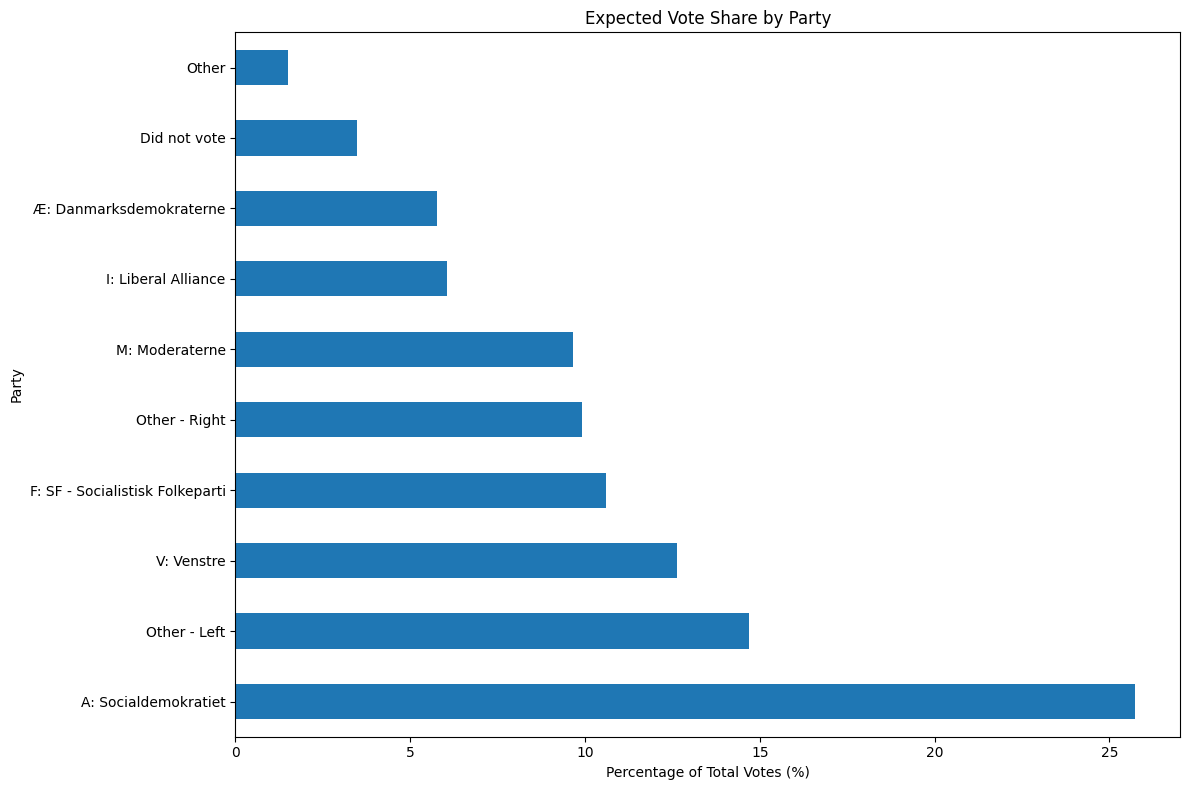

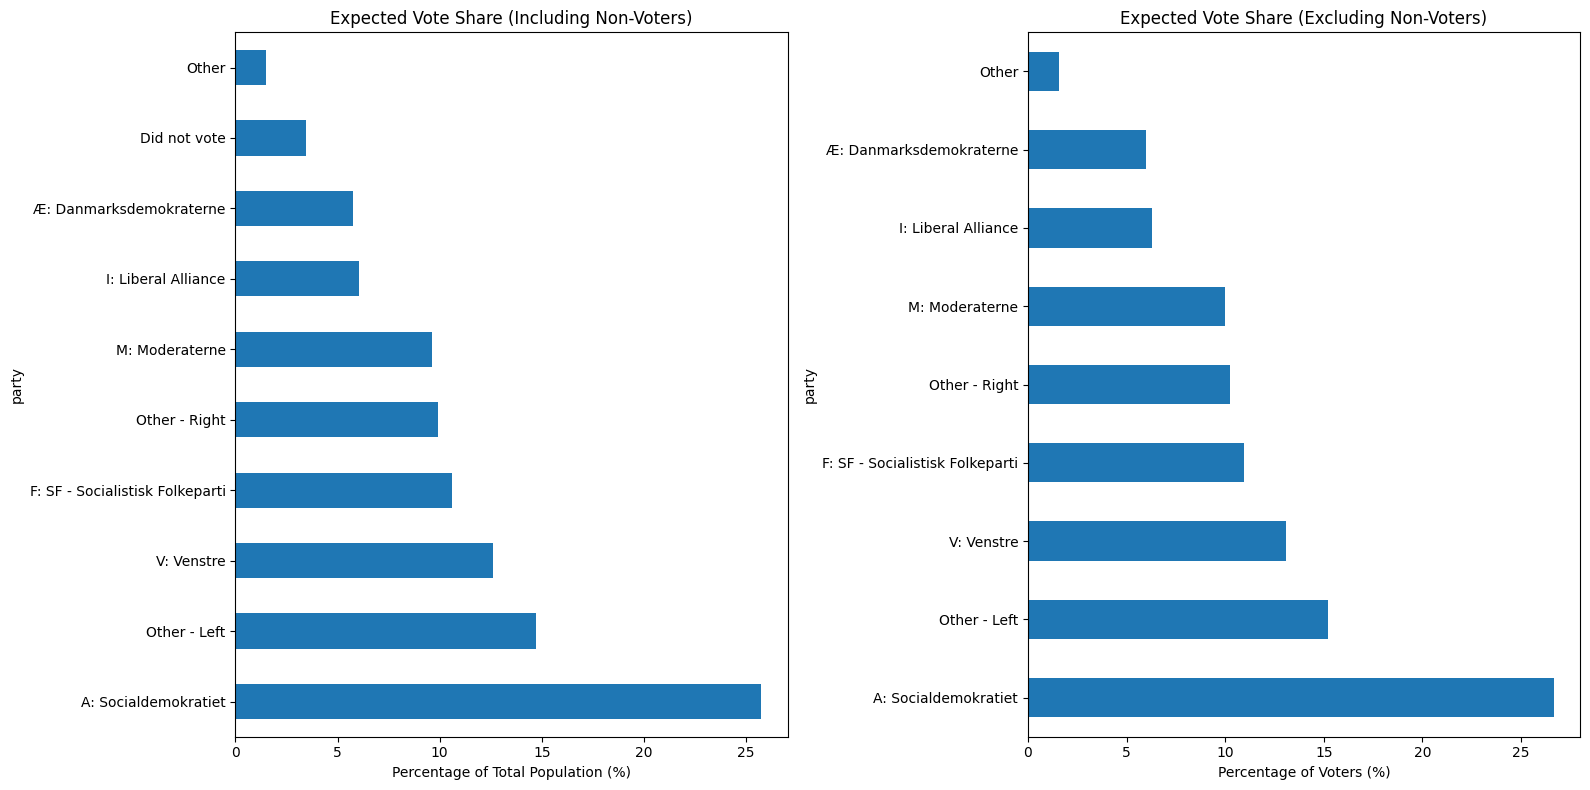

In [13]:
# Calculate total votes (excluding NaN)
total_votes = df['expected_N'].sum()

# Plot 1: Total expected votes by party as percentage
ax1 = df.groupby('party')['expected_N'].sum().sort_values(ascending=False).div(total_votes).mul(100).plot(kind='barh', figsize=(12, 8))
ax1.set_xlabel('Percentage of Total Votes (%)')
ax1.set_ylabel('Party')
ax1.set_title('Expected Vote Share by Party')
plt.tight_layout()
plt.show()

# Plot 2: Side-by-side comparison (excluding "Did not vote")
df_voters = df[df['party'] != 'Did not vote']
total_votes_voters = df_voters['expected_N'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# All votes (including non-voters)
df.groupby('party')['expected_N'].sum().sort_values(ascending=False).div(total_votes).mul(100).plot(kind='barh', ax=ax1)
ax1.set_xlabel('Percentage of Total Population (%)')
ax1.set_title('Expected Vote Share (Including Non-Voters)')

# Voters only
df_voters.groupby('party')['expected_N'].sum().sort_values(ascending=False).div(total_votes_voters).mul(100).plot(kind='barh', ax=ax2)
ax2.set_xlabel('Percentage of Voters (%)')
ax2.set_title('Expected Vote Share (Excluding Non-Voters)')

plt.tight_layout()
plt.show()

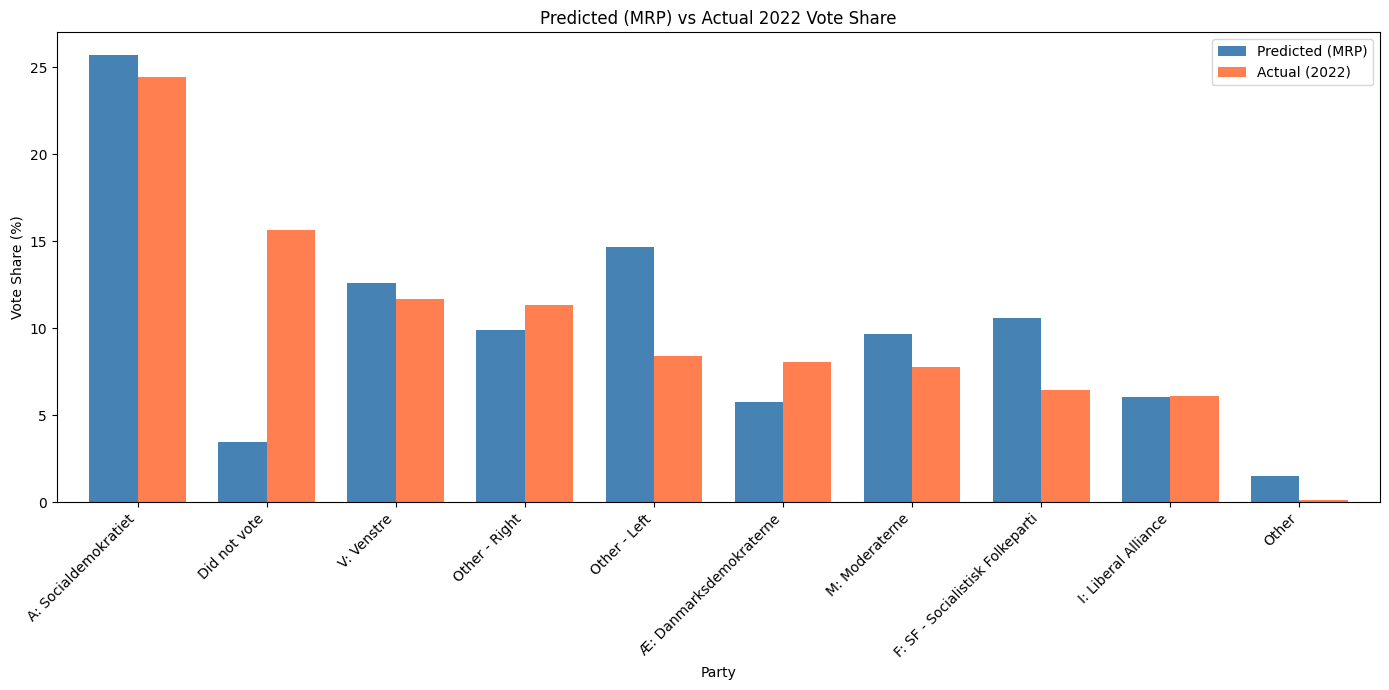

In [ ]:

# Aggregate MRP predicted share from df
mrp_share = df.groupby('party')['expected_N'].sum()
mrp_share = (mrp_share / mrp_share.sum() * 100).rename('Predicted (MRP)')

# Aggregate actual 2022 share from df_elections (mean pop_pct across municipalities)
actual_share = (
    df_elections[df_elections['year'] == 2022]
    .groupby('party')['pop_pct']
    .mean()
    .mul(100)
    .rename('Actual (2022)')
)

# Align non-voter label
actual_share.index = actual_share.index.str.replace('Non-voter', 'Did not vote')

# Combine and sort
compare = pd.DataFrame([mrp_share, actual_share]).T.dropna(how='all')
compare = compare.sort_values('Actual (2022)', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
compare.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], width=0.75)
ax.set_xlabel('Party')
ax.set_ylabel('Vote Share (%)')
ax.set_title('Predicted (MRP) vs Actual 2022 Vote Share')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats
import warnings
from matplotlib.lines import Line2D

# ── Load data ─────────────────────────────────────────────────────────
df_q = pd.read_csv('/Users/danjonaitis/Documents/GitHub/voteframe/python_test/output/initial_extended_frame.csv')
df_actual = pd.read_csv('/Users/danjonaitis/Documents/GitHub/voteframe/python_test/data/election_results.csv')

df_a22 = (df_actual[df_actual['year'] == 2022]
          .copy()
          .assign(party=lambda d: d['party'].str.replace('Non-voter', 'Did not vote')))

merged = (df_q
    .merge(df_a22[['municipality', 'party', 'pop_pct']],
           on=['municipality', 'party'], how='inner')
    .rename(columns={'pop_pct': 'actual', 'median': 'predicted'})
    .assign(
        pred_pct   = lambda d: d['predicted']      * 100,
        actual_pct = lambda d: d['actual']         * 100,
        lo         = lambda d: d['lower_quartile'] * 100,
        hi         = lambda d: d['upper_quartile'] * 100,
    ))

merged['in_iqr'] = (
    (merged['actual'] >= merged['lower_quartile']) &
    (merged['actual'] <= merged['upper_quartile'])
)

# ── Overall metrics ────────────────────────────────────────────────────
coverage = merged['in_iqr'].mean() * 100
sp_r, sp_p = stats.spearmanr(merged['pred_pct'], merged['actual_pct'])
bias = (merged['pred_pct'] - merged['actual_pct']).mean()
rmse = np.sqrt(((merged['pred_pct'] - merged['actual_pct']) ** 2).mean())

print("═══ Overall Metrics ═══")
print(f"IQR Coverage : {coverage:.1f}%")
print(f"Spearman r   : {sp_r:.3f}  (p = {sp_p:.2e})")
print(f"Bias         : {bias:+.3f} pp")
print(f"RMSE         : {rmse:.3f} pp")

# ── Plot helper ────────────────────────────────────────────────────────
def plot_scatter(ax, sub, title, alpha_pts=0.5):
    colors = np.where(sub['in_iqr'], 'steelblue', 'coral')
    ax.hlines(sub['actual_pct'], sub['lo'], sub['hi'],
              colors='#888888', linewidth=0.7, alpha=0.4, zorder=1)
    ax.scatter(sub['pred_pct'], sub['actual_pct'],
               c=colors, s=18, alpha=alpha_pts, zorder=3, linewidths=0)
    vmin = min(sub[['pred_pct', 'actual_pct', 'lo']].min())
    vmax = max(sub[['pred_pct', 'actual_pct', 'hi']].max())
    pad = (vmax - vmin) * 0.05
    ax.plot([vmin - pad, vmax + pad], [vmin - pad, vmax + pad],
            'k--', linewidth=0.8, alpha=0.5, zorder=2)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Predicted (%)', fontsize=8)
    ax.set_ylabel('Actual (%)', fontsize=8)
    ax.tick_params(labelsize=7)
    n = len(sub)
    cov = sub['in_iqr'].mean() * 100
    if n >= 3:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            r, _ = stats.spearmanr(sub['pred_pct'], sub['actual_pct'])
        r_str = f'{r:.2f}' if not np.isnan(r) else 'n/a'
        b  = (sub['pred_pct'] - sub['actual_pct']).mean()
        rm = np.sqrt(((sub['pred_pct'] - sub['actual_pct']) ** 2).mean())
        txt = f'r={r_str}  bias={b:+.2f}\nRMSE={rm:.2f}  cov={cov:.0f}%  n={n}'
    else:
        txt = f'cov={cov:.0f}%  n={n}'
    ax.text(0.04, 0.96, txt, transform=ax.transAxes, fontsize=7,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.75))

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=7, label='Within IQR'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='coral',
           markersize=7, label='Outside IQR'),
    Line2D([0], [0], color='#888888', linewidth=1.5, label='IQR range'),
    Line2D([0], [0], color='k', linestyle='--', linewidth=1, label='1:1 line'),
]

# ── Fig 1: All municipalities × parties ───────────────────────────────
fig_all, ax_all = plt.subplots(figsize=(8, 6))
plot_scatter(ax_all, merged,
             'Predicted vs actual vote share by party. \nEach point is a municipality',
             alpha_pts=0.2)
ax_all.legend(handles=legend_elements, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

# ── Fig 2: Per-party subplots ──────────────────────────────────────────
parties = sorted(merged['party'].unique())
n_parties = len(parties)
n_cols = 4
n_rows = math.ceil(n_parties / n_cols)

fig_p, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_flat = axes.flatten()

for i, party in enumerate(parties):
    sub = merged[merged['party'] == party].copy()
    plot_scatter(axes_flat[i], sub, party, alpha_pts=0.7)

for j in range(n_parties, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig_p.suptitle('Predicted vs actual vote share by party',
               fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


KeyError: "['past_vote'] not in index"

# Raking

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("mrp_outputs/mrp_extended_frame.csv")
municipality_results = pd.read_csv("data/denmark_election_results_with_turnout.csv")
df.head()

,cell_id,age_group,gender,municipality,education_level,N,party,prob,expected_N
0,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,169.486159,Did not vote,0.022092,3.744311
1,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,169.486159,A: Socialdemokratiet,0.246181,41.724301
2,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,169.486159,Other - Left,0.052663,8.925572
3,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,169.486159,V: Venstre,0.107134,18.157806
4,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,169.486159,F: SF - Socialistisk Folkeparti,0.027793,4.710487


In [15]:
df['expected_N'].sum()

4163940.0000000005

                               party   pop_pct
0                              Other  0.001514
97                      Other - Left  0.299313
196                    Other - Right  0.061302
295                   M: Moderaterne  0.076480
394          Æ: Danmarksdemokraterne  0.012802
493             A: Socialdemokratiet  0.147549
592  F: SF - Socialistisk Folkeparti  0.100084
691                       V: Venstre  0.065222
790              I: Liberal Alliance  0.069332
963                     Did not vote  0.166400
0.9999999999999991


In [30]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("mrp_outputs/mrp_extended_frame.csv")
municipality_results = pd.read_csv("data/denmark_election_results_with_turnout.csv")
skeleton = pd.read_csv("data/FOLK1D_HFUDD11_combined.csv")

# ------------------------------------------------------------
# OPTIONAL PARTY RECODING
# ------------------------------------------------------------
other_left = {
    "Ø: Enhedslisten",
    "Å: Alternativet",
    "B: Det Radikale Venstre",
}
other_right = {
    "C: Det Konservative Folkeparti",
    "D: Nye Borgerlige",
    "O: Dansk Folkeparti",
}
other = {
    "Independent candidate",
    "Another party",
    "Voted blank",
}

def recode_party(party: str) -> str:
    if party in other_left:
        return "Other - Left"
    elif party in other_right:
        return "Other - Right"
    elif party in other:
        return "Other"
    return party

# ------------------------------------------------------------
# CLEAN TYPES
# ------------------------------------------------------------
df["municipality"] = df["municipality"].astype(str)
df["gender"] = df["gender"].astype(str)
df["age_group"] = df["age_group"].astype(str)
df["education_level"] = df["education_level"].astype(str)
df["party"] = df["party"].astype(str)
df["expected_N"] = df["expected_N"].astype(float)

municipality_results = municipality_results.loc[
    municipality_results["year"] == 2022
].copy()

municipality_results["municipality"] = municipality_results["municipality"].astype(str)
municipality_results["party"] = municipality_results["party"].astype(str).map(recode_party)
municipality_results["pop_pct"] = municipality_results["pop_pct"].astype(float)

skeleton["municipality"] = skeleton["municipality"].astype(str)
skeleton["gender"] = skeleton["gender"].astype(str)
skeleton["age_group"] = skeleton["age_group"].astype(str)

# skeleton may have "education" instead of "education_level"
if "education" in skeleton.columns and "education_level" not in skeleton.columns:
    skeleton = skeleton.rename(columns={"education": "education_level"})

skeleton["education_level"] = skeleton["education_level"].astype(str)

# ------------------------------------------------------------
# COLLAPSE ELECTION RESULTS TO MUNICIPALITY x PARTY
# ------------------------------------------------------------
municipality_results = (
    municipality_results
    .groupby(["municipality", "party"], as_index=False)["pop_pct"]
    .sum()
)

# Normalize within municipality just in case
municipality_results["pop_pct"] = (
    municipality_results["pop_pct"] /
    municipality_results.groupby("municipality")["pop_pct"].transform("sum")
)

# ------------------------------------------------------------
# BUILD SKELETON JOINT TARGETS
# ------------------------------------------------------------
cell_target_cols = ["municipality", "gender", "age_group", "education_level"]

skeleton_targets = (
    skeleton.groupby(cell_target_cols, as_index=False)["N"]
    .sum()
    .rename(columns={"N": "cell_target"})
)

# ------------------------------------------------------------
# BUILD MUNICIPALITY TOTALS FROM SKELETON
# ------------------------------------------------------------
municipality_totals = (
    skeleton_targets.groupby("municipality", as_index=False)["cell_target"]
    .sum()
    .rename(columns={"cell_target": "municipality_total_N"})
)

# ------------------------------------------------------------
# BUILD MUNICIPALITY x PARTY TARGET COUNTS
# ------------------------------------------------------------
mp_targets = (
    municipality_results
    .merge(municipality_totals, on="municipality", how="inner")
    .assign(target=lambda x: x["pop_pct"] * x["municipality_total_N"])
    .loc[:, ["municipality", "party", "target"]]
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
print("Initial total expected_N:", df["expected_N"].sum())
print("Total municipality-party target:", mp_targets["target"].sum())
print("Total skeleton target:", skeleton_targets["cell_target"].sum())

# These should all be very close
# If not, something is inconsistent in the inputs.

# ------------------------------------------------------------
# KEEP ONLY MATCHING SUPPORT
# ------------------------------------------------------------
# This avoids silent mismatches
mp_target_pairs = set(zip(mp_targets["municipality"], mp_targets["party"]))
df_pairs = set(zip(df["municipality"], df["party"]))

missing_mp_in_df = mp_target_pairs - df_pairs
missing_df_in_mp = df_pairs - mp_target_pairs

print("\nMunicipality-party pairs in targets not in df:", len(missing_mp_in_df))
print("Municipality-party pairs in df not in targets:", len(missing_df_in_mp))

# Cell support check
df_cell_keys = set(
    zip(df["municipality"], df["gender"], df["age_group"], df["education_level"])
)
target_cell_keys = set(
    zip(
        skeleton_targets["municipality"],
        skeleton_targets["gender"],
        skeleton_targets["age_group"],
        skeleton_targets["education_level"],
    )
)

missing_cells_in_df = target_cell_keys - df_cell_keys
missing_cells_in_targets = df_cell_keys - target_cell_keys

print("\nSkeleton cells in targets not in df:", len(missing_cells_in_df))
print("Cells in df not in skeleton targets:", len(missing_cells_in_targets))

# ------------------------------------------------------------
# IPF / RAKING TO BOTH MARGINS
# ------------------------------------------------------------
df_raked = df.copy()
df_raked["expected_N_raked"] = df_raked["expected_N"].astype(float)

max_iter = 200
tol = 1e-8
min_weight = 1e-12

for it in range(max_iter):
    # ---- Step 1: rake to municipality x party ----
    current_mp = (
        df_raked.groupby(["municipality", "party"], as_index=False)["expected_N_raked"]
        .sum()
        .rename(columns={"expected_N_raked": "current"})
    )

    adj_mp = (
        mp_targets.merge(current_mp, on=["municipality", "party"], how="left")
        .assign(current=lambda x: x["current"].fillna(0.0))
    )

    adj_mp["factor_mp"] = np.where(
        adj_mp["current"] > 0,
        adj_mp["target"] / adj_mp["current"],
        1.0,
    )

    df_raked = (
        df_raked.merge(
            adj_mp[["municipality", "party", "factor_mp"]],
            on=["municipality", "party"],
            how="left"
        )
        .assign(
            factor_mp=lambda x: x["factor_mp"].fillna(1.0),
            expected_N_raked=lambda x: np.maximum(
                x["expected_N_raked"] * x["factor_mp"],
                min_weight
            )
        )
        .drop(columns="factor_mp")
    )

    # ---- Step 2: rake to demographic joint cell margin ----
    current_cell = (
        df_raked.groupby(cell_target_cols, as_index=False)["expected_N_raked"]
        .sum()
        .rename(columns={"expected_N_raked": "current"})
    )

    adj_cell = (
        skeleton_targets.merge(current_cell, on=cell_target_cols, how="left")
        .assign(current=lambda x: x["current"].fillna(0.0))
    )

    adj_cell["factor_cell"] = np.where(
        adj_cell["current"] > 0,
        adj_cell["cell_target"] / adj_cell["current"],
        1.0,
    )

    df_raked = (
        df_raked.merge(
            adj_cell[cell_target_cols + ["factor_cell"]],
            on=cell_target_cols,
            how="left"
        )
        .assign(
            factor_cell=lambda x: x["factor_cell"].fillna(1.0),
            expected_N_raked=lambda x: np.maximum(
                x["expected_N_raked"] * x["factor_cell"],
                min_weight
            )
        )
        .drop(columns="factor_cell")
    )

    # ---- convergence check ----
    check_mp = (
        df_raked.groupby(["municipality", "party"])["expected_N_raked"]
        .sum()
        .reset_index()
        .merge(mp_targets, on=["municipality", "party"], how="left")
    )
    check_mp["abs_err"] = (check_mp["expected_N_raked"] - check_mp["target"]).abs()

    check_cell = (
        df_raked.groupby(cell_target_cols)["expected_N_raked"]
        .sum()
        .reset_index()
        .merge(skeleton_targets, on=cell_target_cols, how="left")
    )
    check_cell["abs_err"] = (check_cell["expected_N_raked"] - check_cell["cell_target"]).abs()

    max_err = max(check_mp["abs_err"].max(), check_cell["abs_err"].max())

    if it % 10 == 0 or max_err < tol:
        print(f"Iteration {it + 1}: max abs margin error = {max_err:.10f}")

    if max_err < tol:
        print("Converged.")
        break

# ------------------------------------------------------------
# RECOMPUTE PARTY PROBABILITIES WITHIN CELL
# ------------------------------------------------------------
cell_totals = df_raked.groupby("cell_id")["expected_N_raked"].transform("sum")

df_raked["prob_raked"] = np.where(
    cell_totals > 0,
    df_raked["expected_N_raked"] / cell_totals,
    np.nan
)

# ------------------------------------------------------------
# VALIDATION: BOTH MARGINS
# ------------------------------------------------------------
validation_mp = (
    df_raked.groupby(["municipality", "party"], as_index=False)["expected_N_raked"]
    .sum()
    .rename(columns={"expected_N_raked": "raked"})
    .merge(mp_targets, on=["municipality", "party"], how="left")
)

validation_mp["abs_error"] = (validation_mp["raked"] - validation_mp["target"]).abs()

validation_cell = (
    df_raked.groupby(cell_target_cols, as_index=False)["expected_N_raked"]
    .sum()
    .rename(columns={"expected_N_raked": "raked"})
    .merge(skeleton_targets, on=cell_target_cols, how="left")
)

validation_cell["abs_error"] = (validation_cell["raked"] - validation_cell["cell_target"]).abs()

print("\nMunicipality x party validation:")
print(validation_mp["abs_error"].describe())

print("\nDemographic joint-cell validation:")
print(validation_cell["abs_error"].describe())

# ------------------------------------------------------------
# NATIONAL PARTY SHARES AFTER RAKING
# ------------------------------------------------------------
national_party = (
    df_raked.groupby("party", as_index=False)["expected_N_raked"]
    .sum()
    .rename(columns={"expected_N_raked": "expected_total_raked"})
)

national_total = national_party["expected_total_raked"].sum()
national_party["share_raked"] = national_party["expected_total_raked"] / national_total

print("\nNational party shares after raking:")
print(national_party.sort_values("share_raked", ascending=False))

# ------------------------------------------------------------
# SAVE OUTPUTS
# ------------------------------------------------------------
df_raked.to_csv("mrp_outputs/mrp_extended_frame_raked.csv", index=False)
validation_mp.to_csv("mrp_outputs/mrp_raking_validation_municipality_party.csv", index=False)
validation_cell.to_csv("mrp_outputs/mrp_raking_validation_demographic_cells.csv", index=False)
national_party.to_csv("mrp_outputs/mrp_national_party_shares_raked_both_margins.csv", index=False)

print("\nSaved:")
print("- mrp_outputs/mrp_extended_frame_raked_both_margins.csv")
print("- mrp_outputs/mrp_raking_validation_municipality_party.csv")
print("- mrp_outputs/mrp_raking_validation_demographic_cells.csv")
print("- mrp_outputs/mrp_national_party_shares_raked_both_margins.csv")

Initial total expected_N: 4163940.0000000005
Total municipality-party target: 4163940.0
Total skeleton target: 4163940.0

Municipality-party pairs in targets not in df: 39
Municipality-party pairs in df not in targets: 10

Skeleton cells in targets not in df: 987
Cells in df not in skeleton targets: 286
Iteration 1: max abs margin error = 3146.1713251318
Iteration 11: max abs margin error = 0.0000045350
Iteration 15: max abs margin error = 0.0000000013
Converged.

Municipality x party validation:
count    9.400000e+02
mean     4.714245e-12
std      5.032638e-11
min      0.000000e+00
25%      0.000000e+00
50%      3.552714e-15
75%      4.547474e-13
max      1.309672e-09
Name: abs_error, dtype: float64

Demographic joint-cell validation:
count    2.799700e+04
mean     5.743308e-15
std      3.648395e-14
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.818989e-12
Name: abs_error, dtype: float64

National party shares after raking:
         

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import math
import warnings
from matplotlib.lines import Line2D

# ── Actual results (2022) ──────────────────────────────────────────────
df_a22 = (
    df_actual[df_actual["year"] == 2022]
    .copy()
    .assign(party=lambda d: d["party"].str.replace("Non-voter", "Did not vote"))
)

# ── Build raked municipality-party predicted shares from expected_N_raked ──
raked_muni_party = (
    df_raked
    .dropna(subset=["municipality"])
    .loc[lambda d: d["municipality"].astype(str).str.lower() != "nan"]
    .groupby(["municipality", "party"], as_index=False)["expected_N_raked"]
    .sum()
)

raked_muni_totals = (
    raked_muni_party
    .groupby("municipality", as_index=False)["expected_N_raked"]
    .sum()
    .rename(columns={"expected_N_raked": "municipality_total_raked"})
)

raked_share = (
    raked_muni_party
    .merge(raked_muni_totals, on="municipality", how="left")
    .assign(predicted=lambda d: d["expected_N_raked"] / d["municipality_total_raked"])
)

# ── Merge predicted vs actual ──────────────────────────────────────────
merged = (
    raked_share
    .merge(df_a22[["municipality", "party", "pop_pct"]], on=["municipality", "party"], how="inner")
    .rename(columns={"pop_pct": "actual"})
    .assign(
        pred_pct=lambda d: d["predicted"] * 100,
        actual_pct=lambda d: d["actual"] * 100
    )
)

merged["abs_err_pp"] = (merged["pred_pct"] - merged["actual_pct"]).abs()
merged["within_1pp"] = merged["abs_err_pp"] <= 1.0

# ── Overall metrics ────────────────────────────────────────────────────
coverage = merged["within_1pp"].mean() * 100  # now: within ±1 percentage point
sp_r, sp_p = stats.spearmanr(merged["pred_pct"], merged["actual_pct"])
bias = (merged["pred_pct"] - merged["actual_pct"]).mean()
rmse = np.sqrt(((merged["pred_pct"] - merged["actual_pct"]) ** 2).mean())

print("═══ Overall Metrics (Raked) ═══")
print(f"Within ±1pp : {coverage:.1f}%")
print(f"Spearman r  : {sp_r:.3f}  (p = {sp_p:.2e})")
print(f"Bias        : {bias:+.3f} pp")
print(f"RMSE        : {rmse:.3f} pp")

# ── Plot helper ────────────────────────────────────────────────────────
def plot_scatter(ax, sub, title, alpha_pts=0.5):
    colors = np.where(sub["within_1pp"], "steelblue", "coral")
    ax.scatter(
        sub["pred_pct"], sub["actual_pct"],
        c=colors, s=18, alpha=alpha_pts, zorder=3, linewidths=0
    )

    vmin = min(sub[["pred_pct", "actual_pct"]].min())
    vmax = max(sub[["pred_pct", "actual_pct"]].max())
    pad = (vmax - vmin) * 0.05 if vmax > vmin else 1

    ax.plot(
        [vmin - pad, vmax + pad], [vmin - pad, vmax + pad],
        "k--", linewidth=0.8, alpha=0.5, zorder=2
    )

    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Predicted (%)", fontsize=8)
    ax.set_ylabel("Actual (%)", fontsize=8)
    ax.tick_params(labelsize=7)

    n = len(sub)
    cov = sub["within_1pp"].mean() * 100
    if n >= 3:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r, _ = stats.spearmanr(sub["pred_pct"], sub["actual_pct"])
        r_str = f"{r:.2f}" if not np.isnan(r) else "n/a"
        b = (sub["pred_pct"] - sub["actual_pct"]).mean()
        rm = np.sqrt(((sub["pred_pct"] - sub["actual_pct"]) ** 2).mean())
        txt = f"r={r_str}  bias={b:+.2f}\nRMSE={rm:.2f}  ±1pp={cov:.0f}%  n={n}"
    else:
        txt = f"±1pp={cov:.0f}%  n={n}"

    ax.text(
        0.04, 0.96, txt, transform=ax.transAxes, fontsize=7,
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75)
    )

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="steelblue",
           markersize=7, label="Within ±1pp"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="coral",
           markersize=7, label="Outside ±1pp"),
    Line2D([0], [0], color="k", linestyle="--", linewidth=1, label="1:1 line"),
]

# ── Fig 1: All municipalities × parties ───────────────────────────────
fig_all, ax_all = plt.subplots(figsize=(8, 6))
plot_scatter(
    ax_all, merged,
    "Raked predicted vs actual vote share by party.\nEach point is a municipality",
    alpha_pts=0.2
)
ax_all.legend(handles=legend_elements, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# ── Fig 2: Per-party subplots ──────────────────────────────────────────
parties = sorted(merged["party"].unique())
n_parties = len(parties)
n_cols = 4
n_rows = math.ceil(n_parties / n_cols)

fig_p, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_flat = axes.flatten()

for i, party in enumerate(parties):
    sub = merged[merged["party"] == party].copy()
    plot_scatter(axes_flat[i], sub, party, alpha_pts=0.7)

for j in range(n_parties, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig_p.suptitle("Raked predicted vs actual vote share by party", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


NameError: name 'df_actual' is not defined

In [22]:
# drop N
# df_raked = df_raked.drop(columns=["N", "prob", "expected_N", "prob_raked"])
df_raked
# round expected_N_raked to integer since it represents counts and rename to N
df_raked = df_raked.rename(columns={"expected_N_raked": "N"})
df_raked["N"] = df_raked["N"].round().astype(int)
df_raked.head()

,cell_id,age_group,gender,municipality,education_level,party,N
0,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,Did not vote,14
1,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,A: Socialdemokratiet,34
2,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,Other - Left,5
3,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,V: Venstre,23
4,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,F: SF - Socialistisk Folkeparti,3


In [1]:
missing_cells_in_df

NameError: name 'missing_cells_in_df' is not defined

In [27]:
df_raked.head()

,cell_id,age_group,gender,municipality,education_level,vote_2022,N
0,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,Did not vote,14
1,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,A: Socialdemokratiet,34
2,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,Other - Left,5
3,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,V: Venstre,23
4,1,20-24,Men,Aabenraa,H1020 Primary school 7th-9th grade,F: SF - Socialistisk Folkeparti,3
